In [14]:
import os
from pathlib import Path
from typing import Dict, List, Optional, Union
import pandas as pd
import matplotlib.pyplot as plt
import pytz
from datetime import timezone
import requests
import json
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import pandas as pd
import plotly.express as px
import vis as vis
import sys
import re
import contextlib

DEFAULT_TIMEZONE = "America/New_York"

COLUMN_ALIASES: Dict[str, List[str]] = {
    "time":        [
        "RECORDED_TIME", "recorded_time", "time", "timestamp", 
        "record_date", "flowsheet_record_datetime", "flowsheet_record_date"
    ],
    "value":       [
        "MEAS_VALUE", "meas_value", "value", "result", 
        "result_value", "measurement_value"
    ],
    "measure":     [
        "FLO_MEAS_NAME", "flo_meas_name", "MEAS_NAME", "measure", "name", 
        "DISP_NAME", "flowsheet_measurement_name", "flowsheet_measurement_display_name"
    ],
    "unit":        [
        "fdgDisplayName", "units", "unit", "unit_name", "measurement_units"
    ],
    "flowsheet_id":[
        "FLT_ID", "mrn", "FLO_MEAS_ID", "flo_meas_id", "flowsheet_measurement_id"
    ],
}

## Set flowsheet path and plot parameters


## Patient Configuration
Edit the PATIENT_LIST below to add or remove patients. Each patient entry should include their MRN and optionally their name for easier identification.

In [15]:
# ============================================================
# PATIENT LIST CONFIGURATION
# Load patients from environment variables
# ============================================================

from config import Config

# Load patient list from environment variables
PATIENT_LIST = Config.get_patient_list_from_env()

# If you need to add more patient details (names, notes), you can extend the list here:
# PATIENT_LIST[0]["name"] = "John Doe"
# PATIENT_LIST[0]["notes"] = "Sample patient"

print(f"Loaded {len(PATIENT_LIST)} patient(s) from environment configuration.")
if PATIENT_LIST:
    print("Patient MRNs loaded (hidden for privacy)")
else:
    print("⚠️  No patients configured. Please check your .env file.")

Loaded 2 patient(s) from environment configuration.
Patient MRNs loaded (hidden for privacy)


## Patient Selector
Use the dropdown below to select a patient. The notebook will automatically load data for the selected patient.

In [16]:
import ipywidgets as widgets
from IPython.display import display, HTML
from datetime import datetime, timedelta

# Create dropdown options from patient list
patient_options = []
for patient in PATIENT_LIST:
    mrn = patient["mrn"]
    name = patient.get("name", "Unknown")
    notes = patient.get("notes", "")
    # Format: "MRN: 1234567891 - John Doe (notes)"
    label = f"MRN: {mrn} - {name}"
    if notes:
        label += f" ({notes})"
    patient_options.append((label, mrn))

# Create the patient dropdown widget
patient_selector = widgets.Dropdown(
    options=patient_options,
    description='Patient:',
    disabled=False,
    style={'description_width': '80px'},
    layout=widgets.Layout(width='600px')
)

# Create date picker widgets
# Default to a reasonable date range
default_start = datetime(2025, 2, 21)
default_end = datetime(2026, 5, 3)

start_date_picker = widgets.DatePicker(
    description='Start Date:',
    disabled=False,
    value=default_start,
    style={'description_width': '80px'},
    layout=widgets.Layout(width='300px')
)

end_date_picker = widgets.DatePicker(
    description='End Date:',
    disabled=False,
    value=default_end,
    style={'description_width': '80px'},
    layout=widgets.Layout(width='300px')
)

# Create output widget to show selected patient info
patient_info_output = widgets.Output()

def on_patient_change(change):
    """Callback when patient selection changes"""
    selected_mrn = change['new']
    
    # Find the selected patient details
    selected_patient = None
    for patient in PATIENT_LIST:
        if patient["mrn"] == selected_mrn:
            selected_patient = patient
            break
    
    # Update the info display
    with patient_info_output:
        patient_info_output.clear_output()
        if selected_patient:
            print(f"Selected Patient Information:")
            print(f"  MRN: {selected_patient['mrn']}")
            print(f"  Name: {selected_patient.get('name', 'N/A')}")
            if 'notes' in selected_patient and selected_patient['notes']:
                print(f"  Notes: {selected_patient['notes']}")
            print(f"\nDate Range: {start_date_picker.value} to {end_date_picker.value}")
            print(f"\nThe notebook will use these settings for all subsequent operations.")

def on_date_change(change):
    """Callback when date selection changes"""
    on_patient_change({'new': patient_selector.value})

# Attach the callbacks
patient_selector.observe(on_patient_change, names='value')
start_date_picker.observe(on_date_change, names='value')
end_date_picker.observe(on_date_change, names='value')

# Display the selectors
display(patient_selector)
display(widgets.HBox([start_date_picker, end_date_picker]))
display(patient_info_output)

# Trigger initial display
on_patient_change({'new': patient_selector.value})

print("\nPatient and date selectors ready. Use the dropdowns above to configure your analysis.")

Dropdown(description='Patient:', layout=Layout(width='600px'), options=(('MRN: 1234567891 - Patient 1 (Loaded …

Output()


Patient and date selectors ready. Use the dropdowns above to configure your analysis.


In [17]:
def _auto_map_columns(df: pd.DataFrame, overrides: Optional[Dict[str, str]] = None) -> Dict[str, str]:
    mapping: Dict[str, str] = {}
    overrides = overrides or {}
    cols_lower = {c.lower(): c for c in df.columns}

    def pick(key: str) -> Optional[str]:
        if key in overrides and overrides[key] in df.columns:
            return overrides[key]
        for alias in COLUMN_ALIASES.get(key, []):
            if alias in df.columns:
                return alias
            if alias.lower() in cols_lower:
                return cols_lower[alias.lower()]
        return None

    for k in COLUMN_ALIASES:
        col = pick(k)
        if col:
            mapping[k] = col
    return mapping

def _ensure_tz(dt_series: pd.Series, tz: str) -> pd.Series:
    tzinfo = pytz.timezone(tz)
    dt = pd.to_datetime(dt_series, errors="coerce", utc=False)
    has_tz = getattr(dt.dt, "tz", None) is not None
    return dt.dt.tz_convert(tzinfo) if has_tz else dt.dt.tz_localize(tzinfo)

def _to_aware(ts_like, tz: str) -> pd.Timestamp:
    tzinfo = pytz.timezone(tz)
    t = pd.to_datetime(ts_like, errors="coerce")
    if pd.isna(t):
        raise ValueError(f"Unparseable date: {ts_like}")
    return t.tz_localize(tzinfo) if t.tzinfo is None else t.tz_convert(tzinfo)

def _is_probably_excel(path: str) -> bool:
    ext = os.path.splitext(path)[1].lower()
    if ext in (".xls", ".xlsx", ".xlsm", ".xlsb"):
        return True
    try:
        with open(path, "rb") as f:
            return f.read(4).startswith(b"PK\x03\x04")
    except Exception:
        return False

def _select_excel_sheet(obj, sheet_name: Optional[Union[str, int]]):
    if isinstance(obj, dict):
        sheets = list(obj.keys())
        if sheet_name is None:
            return obj[sheets[0]]
        if isinstance(sheet_name, int):
            return obj[sheets[sheet_name]]
        if sheet_name in obj:
            return obj[sheet_name]
        return obj[sheets[0]]
    return obj

# ----------------- NEW: MRN INT COERCION HELPERS -----------------

_DIGITS = re.compile(r"\d+")

def _coerce_mrn_cell_to_int(x) -> Optional[int]:
    """Convert a single MRN cell to int safely (handles strings, floats, ints)."""
    if pd.isna(x):
        return None
    # Already numeric (Excel often gives float for big ints)
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and np.isfinite(x):
        return int(x)
    # String-like: extract digits
    s = str(x).strip()
    # common artifacts like '9.876e+09' or '9876-543-210' or '  9876543210 '
    # try direct int cast first
    try:
        return int(s)
    except Exception:
        pass
    m = _DIGITS.findall(s)
    if not m:
        return None
    # join all digit runs (conservative: or choose the longest run)
    # Usually MRN is the longest contiguous digit run
    longest = max(m, key=len)
    try:
        return int(longest)
    except Exception:
        return None

def _coerce_mrn_series_to_Int64(s: pd.Series) -> pd.Series:
    """Convert a whole MRN series to pandas nullable Int64 dtype."""
    coerced = s.map(_coerce_mrn_cell_to_int)
    return pd.Series(coerced, index=s.index, dtype="Int64")

def _normalize_mrn_filter(mrn: Optional[Union[int, str, List[Union[int, str]]]]) -> Optional[set]:
    """Return a set of ints for filtering, or None if no filter."""
    if mrn is None:
        return None
    vals = mrn if isinstance(mrn, (list, tuple, set)) else [mrn]
    out = []
    for v in vals:
        iv = _coerce_mrn_cell_to_int(v)
        if iv is not None:
            out.append(iv)
    return set(out) if out else None

# ---------------------------------------------------------------

def get_flowsheet_data(
    file_path: str,
    sheet_name: Optional[Union[str, int]] = None,
    column_overrides: Optional[Dict[str, str]] = None,
    include_measures: Optional[List[str]] = None,
    mrn: Optional[Union[str, int, List[Union[str, int]]]] = None,
    flowsheet_id: Optional[Union[str, int]] = None,
    tz: str = DEFAULT_TIMEZONE,
    # NEW: date window options
    start_date: Optional[Union[str, pd.Timestamp]] = None,
    end_date: Optional[Union[str, pd.Timestamp]] = None,
    # Optional: select bounds from time-sorted iloc indices (after MRN/measure filter)
    start_iloc: Optional[int] = None,
    end_iloc: Optional[int] = None,
    inclusive: str = "both",  # "both" | "left" | "right" | "neither"
) -> pd.DataFrame:
    """Load & clean flowsheet; returns standardized columns:
       __time, __day, __measure, __value, __unit, __mrn (string, if present), __mrn_int (nullable Int64, if present).
    """

    # Load file
    if _is_probably_excel(file_path):
        try:
            raw = pd.read_excel(file_path, sheet_name=sheet_name if sheet_name is not None else None)
        except Exception:
            raw = pd.read_csv(file_path, encoding="utf-8", engine="python")
    else:
        raw = pd.read_csv(file_path, encoding="utf-8", engine="python")

    df = _select_excel_sheet(raw, sheet_name)
    mapping = _auto_map_columns(df, overrides=column_overrides)

    # Required cols
    required = ["time", "value", "measure"]
    missing = [k for k in required if k not in mapping]
    if missing:
        raise ValueError(f"Missing required columns (or overrides) for {missing}. Detected mapping: {mapping}")

    # Standardize
    df = df.copy()
    df["__value"] = pd.to_numeric(df[mapping["value"]], errors="coerce")
    df = df.dropna(subset=["__value"])
    df["__measure"] = df[mapping["measure"]].astype(str)
    df["__time"] = _ensure_tz(df[mapping["time"]], tz=tz)
    df["__day"] = df["__time"].dt.date

    # Units
    unit_col = mapping.get("unit")
    df["__unit"] = df[unit_col].astype(str) if unit_col else ""

    # MRN (now normalized to Int64 in __mrn_int, keep __mrn string for reference)
    mrn_col = mapping.get("mrn")
    mrn_filter_set = _normalize_mrn_filter(mrn)
    if mrn_col is not None:
        # Keep the original text (for debugging / joins) but make int the primary
        df["__mrn"] = df[mrn_col].astype(str).str.strip()
        df["__mrn_int"] = _coerce_mrn_series_to_Int64(df[mrn_col])
        if mrn_filter_set is not None:
            df = df[df["__mrn_int"].isin(mrn_filter_set)]

    # Optional flowsheet_id filter (coerce to string compare is fine; IDs are stable)
    if flowsheet_id is not None and mapping.get("flowsheet_id"):
        df = df[df[mapping["flowsheet_id"]].astype(str) == str(flowsheet_id)]

    # Optional measure filter
    if include_measures:
        wanted = {m.lower() for m in include_measures}
        df = df[df["__measure"].str.lower().isin(wanted)]

    # Compute date bounds
    lower, upper = None, None
    if start_date is not None:
        lower = _to_aware(start_date, tz)
    if end_date is not None:
        upper = _to_aware(end_date, tz)

    if start_iloc is not None or end_iloc is not None:
        t_sorted = df.sort_values("__time")
        if start_iloc is not None and len(t_sorted) > 0:
            lower_iloc = t_sorted.iloc[start_iloc]["__time"]
            lower = max(filter(None, [lower, lower_iloc]), default=lower_iloc)
        if end_iloc is not None and len(t_sorted) > 0:
            upper_iloc = t_sorted.iloc[end_iloc]["__time"]
            upper = min(filter(None, [upper, upper_iloc]), default=upper_iloc)

    # Apply date filter
    if (lower is not None) or (upper is not None):
        if lower is not None:
            df = df[df["__time"] > lower] if inclusive in ("right", "neither") else df[df["__time"] >= lower]
        if upper is not None:
            df = df[df["__time"] < upper] if inclusive in ("left", "neither") else df[df["__time"] <= upper]

    return df


In [18]:
# Get the selected patient's MRN and date range from the selectors
mrn_filter = patient_selector.value
start_date = start_date_picker.value.strftime('%Y-%m-%d') if start_date_picker.value else None
end_date = end_date_picker.value.strftime('%Y-%m-%d') if end_date_picker.value else None

# Load flowsheet path from environment
from config import Config
flowsheet_path = Config.FLOWSHEET_FILE

print(f"Loading data for selected patient")
print(f"Date range: {start_date} to {end_date}")
print(f"Flowsheet file: {flowsheet_path}")

df = get_flowsheet_data(
    file_path=flowsheet_path,
    sheet_name=0,
    mrn=mrn_filter,
    tz=DEFAULT_TIMEZONE,
    start_date=start_date,
    end_date=end_date,
    inclusive="both",
)

try:
    from IPython.display import display
    display(df.head())
except Exception:
    print(df.head())

print("Rows loaded:", len(df))

Loading data for selected patient
Date range: 2025-02-21 to 2026-05-03
Flowsheet file: Sample Flowsheet_10-27-2025.xlsx


,email_address,first_name,last_name,mrn,admit_date,token,inpatient_start_date,table_number,ring_size,ring_serial_number,...,measurement_line,measurement_value,measurement_units,row_update_user_id,row_update_datetime,__value,__measure,__time,__day,__unit
0,cardioourastudy+10@med.cornell.edu,John,Doe,1234567891,2025-05-16,OILYI27TEJ2HNZAMFZ5QZQZIEZQKZTPK,NaN,NaN,NaN,NaN,...,15,104.78,kg,NYH\dym9015,2025-10-22 14:40:24,104.78,r fs nicu calculator current weight,2025-06-28 00:00:00-04:00,2025-06-28,kg
1,cardioourastudy+10@med.cornell.edu,John,Doe,1234567891,2025-05-16,OILYI27TEJ2HNZAMFZ5QZQZIEZQKZTPK,NaN,NaN,NaN,NaN,...,16,104.78,kg,NYH\dym9015,2025-10-22 14:40:24,104.78,r fs nicu calculator weight used,2025-06-29 00:00:00-04:00,2025-06-29,kg
2,cardioourastudy+10@med.cornell.edu,John,Doe,1234567891,2025-05-16,OILYI27TEJ2HNZAMFZ5QZQZIEZQKZTPK,NaN,NaN,NaN,NaN,...,17,0.00,ml/kg/hr,NYH\dym9015,2025-10-22 14:40:24,0.00,r fs nicu calculator total intake 24 hrs,2025-06-30 00:00:00-04:00,2025-06-30,ml/kg/hr
3,cardioourastudy+6@med.cornell.edu,Mary,Ann,9876543219,2025-05-20,9HGUFSGIWRWFW77BCSPOKXGLYPI5V5AY,NaN,NaN,NaN,NaN,...,18,0.00,ml,NYH\dym9015,2025-10-22 14:40:24,0.00,r fs nicu calculator display total intake,2025-07-05 00:00:00-04:00,2025-07-05,ml
4,cardioourastudy+6@med.cornell.edu,Mary,Ann,9876543219,2025-05-20,9HGUFSGIWRWFW77BCSPOKXGLYPI5V5AY,NaN,NaN,NaN,NaN,...,19,2.10,sq meters,NYH\dym9015,2025-10-22 14:40:24,2.10,r bsa,2025-07-05 00:00:00-04:00,2025-07-05,sq meters


Rows loaded: 6


## Plot flowsheet values

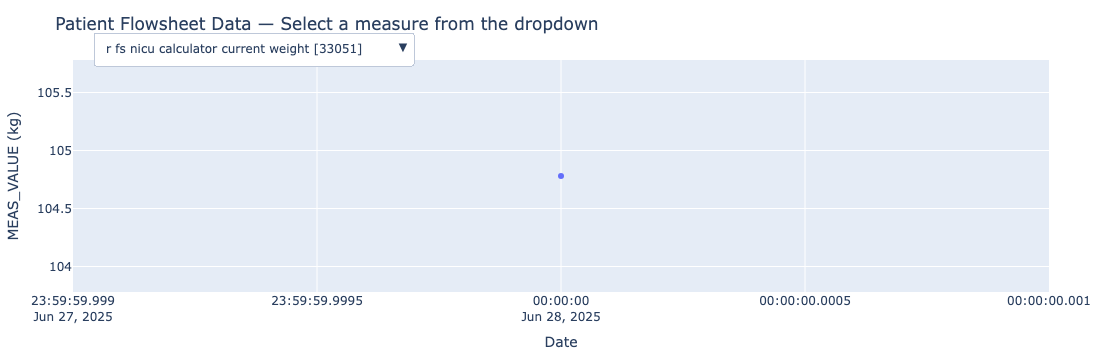

In [19]:
import pandas as pd
import plotly.graph_objects as go
from datetime import timezone
import pytz
from config import Config

# Load configuration from environment
FILE_PATH = Config.FLOWSHEET_FILE
DEFAULT_TIMEZONE = Config.DEFAULT_TIMEZONE
SHEET_INDEX = 0

# Get MRN from patient selector
MRN_FILTER = patient_selector.value

COLUMN_ALIASES = {
    "time":        [
        "RECORDED_TIME", "recorded_time", "time", "timestamp", "record_date", 
        "date", "__time", "flowsheet_record_datetime", "flowsheet_record_date"
    ],
    "value":       [
        "MEAS_VALUE", "meas_value", "value", "result", "result_value", 
        "__value", "measurement_value"
    ],
    "measure":     [
        "FLO_MEAS_NAME", "flo_meas_name", "MEAS_NAME", "measure", "name", 
        "DISP_NAME", "__measure", "flowsheet_measurement_name", "flowsheet_measurement_display_name"
    ],
    "unit":        [
        "fdgDisplayName", "units", "unit", "unit_name", "__unit", "measurement_units"
    ],
    "mrn":         [
        "MRN", "mrn", "patient_mrn", "patient mrn", "patient_id", 
        "patientid", "pt_mrn", "__mrn"
    ],
    "flowsheet_id":[
        "FLO_MEAS_ID", "flo_meas_id", "FLT_ID", "flowsheet_measurement_id"
    ],
}

def _auto_map_columns(df: pd.DataFrame, overrides=None) -> dict:
    mapping = {}
    overrides = overrides or {}
    lower = {c.lower(): c for c in df.columns}
    def pick(key: str):
        if key in overrides and overrides[key] in df.columns:
            return overrides[key]
        for alias in COLUMN_ALIASES.get(key, []):
            if alias in df.columns:
                return alias
            if alias.lower() in lower:
                return lower[alias.lower()]
        return None
    for k in COLUMN_ALIASES:
        c = pick(k)
        if c: mapping[k] = c
    return mapping

def _ensure_tz(dt_series: pd.Series, tz: str) -> pd.Series:
    tzinfo = pytz.timezone(tz)
    dt = pd.to_datetime(dt_series, errors="coerce", utc=False)
    has_tz = getattr(dt.dt, "tz", None) is not None
    return dt.dt.tz_convert(tzinfo) if has_tz else dt.dt.tz_localize(tzinfo)

# --- Load data (Excel or CSV) ---
ext = os.path.splitext(FILE_PATH)[1].lower()
if ext in (".xlsx", ".xls", ".xlsm", ".xlsb"):
    df_raw = pd.read_excel(FILE_PATH, sheet_name=SHEET_INDEX)
else:
    df_raw = pd.read_csv(FILE_PATH, encoding="utf-8", engine="python")

# --- Map & standardize columns ---
m = _auto_map_columns(df_raw)
req = ["time", "value", "measure", "mrn"]
missing = [k for k in req if k not in m]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Detected mapping: {m}")

df = df_raw.copy()
df["__time"]    = _ensure_tz(df[m["time"]], tz=DEFAULT_TIMEZONE)
df["__value"]   = pd.to_numeric(df[m["value"]], errors="coerce")
df["__measure"] = df[m["measure"]].astype(str)
df["__mrn"]     = df[m["mrn"]].astype(str).str.strip()
unit_col = m.get("unit")
df["__unit"] = df[unit_col].astype(str) if unit_col else ""

# --- Filter by MRN ---
df = df[df["__mrn"] == str(MRN_FILTER).strip()].dropna(subset=["__time","__value","__measure"])
if df.empty:
    raise ValueError(f"No rows found for selected patient")

# --- Build one entry per measure (label = NAME [ID] if ID available) ---
id_col = m.get("flowsheet_id")
if id_col and id_col in df.columns:
    labels_series = (df["__measure"] + " [" + df[id_col].astype(str) + "]").fillna(df["__measure"])
else:
    labels_series = df["__measure"]

pairs = (
    pd.DataFrame({"label": labels_series, "measure": df["__measure"]})
    .drop_duplicates()
    .sort_values("label")
    .reset_index(drop=True)
)

# Keep only measures that actually have data
entries = []
for _, row in pairs.iterrows():
    meas_name = row["measure"]
    label = row["label"]
    sub = df[df["__measure"] == meas_name].sort_values("__time").dropna(subset=["__time", "__value"])
    if sub.empty:
        continue
    unit_here = ""
    if "__unit" in sub.columns and sub["__unit"].notna().any():
        try:
            unit_here = f" ({sub['__unit'].dropna().mode().iat[0]})"
        except Exception:
            pass
    entries.append({"label": label, "measure": meas_name, "data": sub, "unit": unit_here})

if not entries:
    raise ValueError("No non-empty measures found for this patient.")

# --- Create Plotly traces (one per measure) ---
traces = []
for idx, ent in enumerate(entries):
    sub = ent["data"]
    traces.append(go.Scatter(
        x=sub["__time"],
        y=sub["__value"],
        mode="lines+markers",
        name=ent["label"],
        visible=(idx == 0),  # first visible by default
        hovertemplate="%{x|%Y-%m-%d %H:%M}<br>Value=%{y}<extra></extra>",
    ))

fig = go.Figure(data=traces)

# Initial axis labels
default_unit = entries[0]["unit"] if entries else ""
fig.update_layout(
    title=f"Patient Flowsheet Data — Select a measure from the dropdown",
    xaxis_title="Date",
    yaxis_title=f"MEAS_VALUE{default_unit}",
    margin=dict(l=60, r=20, t=60, b=50),
)

# --- Dropdown to toggle which measure is visible ---
buttons = []
for idx, ent in enumerate(entries):
    visual = [False] * len(entries)
    visual[idx] = True
    buttons.append(dict(
        label=ent["label"],
        method="update",
        args=[
            {"visible": visual},
            {"yaxis": {"title": f"MEAS_VALUE{ent['unit']}"}}
        ],
    ))

fig.update_layout(
    updatemenus=[dict(
        type="dropdown",
        x=0.02, y=1.12, xanchor="left", yanchor="top",
        buttons=buttons, direction="down", showactive=True
    )]
)

fig.show()

In [20]:
# function for retrieving oura data
def get_oura_data(oura_token, d_type="workout", start_date="2023-01-01", end_date="2026-05-01"):
    url = f'https://api.ouraring.com/v2/usercollection/{d_type}' 
    
    params={ 
        'start_date': start_date, 
        'end_date': end_date
    }
    headers = { 
        'Authorization': f'Bearer {oura_token}' 
    }
    
    try:
        response = requests.request('GET', url, headers=headers, params=params)
        response.raise_for_status()  # Raise exception for HTTP errors
        
        json_data = response.json()
        
        # Check if 'data' key exists in the response
        if 'data' not in json_data:
            print(f"⚠️  Warning: No 'data' field in Oura API response for {d_type}")
            print(f"Response: {response.text[:200]}")  # Print first 200 chars
            # Return empty DataFrame instead of crashing
            return pd.DataFrame()
        
        df = pd.DataFrame(json_data["data"])
        return df
        
    except requests.exceptions.RequestException as e:
        print(f"❌ Error fetching Oura data for {d_type}: {e}")
        return pd.DataFrame()
    except Exception as e:
        print(f"❌ Unexpected error processing Oura data for {d_type}: {e}")
        return pd.DataFrame()

# Extract API token from flowsheet data for selected patient
mrn_key = "__mrn" if "__mrn" in df.columns else "mrn"
mask = df[mrn_key].astype(str).str.strip() == str(mrn_filter).strip()
if not df.loc[mask, "token"].dropna().empty:
    api_token = df.loc[mask, "token"].dropna().astype(str).str.strip().iloc[0]
    print("Oura API token retrieved from flowsheet for selected patient")
else:
    print("No token found in flowsheet for selected patient, using environment variable")
    from config import Config
    api_token = Config.OURA_API_TOKEN

Oura API token retrieved from flowsheet for selected patient


In [21]:
# Use demo token from environment for visualization if needed
# This allows testing with demo data when real patient data is not available
from config import Config
demo_token = Config.OURA_API_TOKEN_DEMO

# Use demo token if the retrieved token is not valid or for testing
# Comment out the line below to use the patient's actual token
if demo_token:
    print("Using demo Oura API token from environment for testing")
    api_token = demo_token

# Fetch Oura data with error handling
print("Fetching Oura Ring data...")
activity = get_oura_data(api_token, "daily_activity", start_date, end_date)
work_out = get_oura_data(api_token, "workout", start_date, end_date)
sleep = get_oura_data(api_token, "sleep", start_date, end_date)
d_sleep = get_oura_data(api_token, "daily_sleep", start_date, end_date)
d_readiness = get_oura_data(api_token, "daily_readiness", start_date, end_date)
hr = get_oura_data(api_token, "heartrate", start_date, end_date)
daily_spo2 = get_oura_data(api_token, "daily_spo2", start_date, end_date)  # NEW: Fetch SpO2 data

# Process SpO2 data
if not daily_spo2.empty and 'spo2_percentage' in daily_spo2.columns:
    # Flatten the nested spo2_percentage dict to get the average value
    daily_spo2['average_spo2'] = daily_spo2['spo2_percentage'].apply(
        lambda x: x.get('average') if isinstance(x, dict) else x
    )
    print(f"✓ Successfully fetched SpO2 data: {len(daily_spo2)} days")
elif not daily_spo2.empty:
    print(f"⚠️  SpO2 data fetched but 'spo2_percentage' column not found")
    print(f"   Available columns: {daily_spo2.columns.tolist()}")
else:
    print("⚠️  Warning: No SpO2 data available from Oura Ring")

# Check if we have sleep data (required for merged data)
if sleep.empty or 'day' not in sleep.columns:
    print("\n⚠️  Warning: No sleep data available from Oura Ring")
    print("Cannot create merged dataset. Please check:")
    print("  1. The API token is valid")
    print("  2. The date range contains data")
    print("  3. The user has Oura Ring data for the specified dates")
    merged_oura_data = pd.DataFrame()
else:
    # Merge data safely
    required_sleep_cols = ["day", "average_hrv", "lowest_heart_rate", "total_sleep_duration", 
                          "average_breath", "hrv", "heart_rate",
                          "deep_sleep_duration", "light_sleep_duration", "rem_sleep_duration"]  # Added sleep stage columns
    available_sleep_cols = [col for col in required_sleep_cols if col in sleep.columns]
    
    if len(available_sleep_cols) < 2:  # Need at least day + one metric
        print(f"⚠️  Warning: Sleep data missing required columns")
        merged_oura_data = pd.DataFrame()
    else:
        merged_oura_data = sleep[available_sleep_cols].copy()
        
        # Merge readiness data if available
        if not d_readiness.empty and 'day' in d_readiness.columns and 'temperature_deviation' in d_readiness.columns:
            merged_oura_data = merged_oura_data.merge(d_readiness[["day", "temperature_deviation"]], "left", on="day")
        
        # Merge activity data if available
        if not activity.empty and 'day' in activity.columns and 'steps' in activity.columns:
            merged_oura_data = merged_oura_data.merge(activity[["day", "steps"]], "left", on="day")
        
        print(f"✓ Successfully merged Oura data: {len(merged_oura_data)} days")

merged_oura_data

Using demo Oura API token from environment for testing
Fetching Oura Ring data...
✓ Successfully fetched SpO2 data: 78 days
✓ Successfully merged Oura data: 91 days


,day,average_hrv,lowest_heart_rate,total_sleep_duration,average_breath,hrv,heart_rate,deep_sleep_duration,light_sleep_duration,rem_sleep_duration,temperature_deviation,steps
0,2025-03-14,NaN,NaN,420,18.625,"{'interval': 300.0, 'items': [None, None, None...","{'interval': 300.0, 'items': [None, None, None...",0,420,0,NaN,NaN
1,2025-03-22,69.0,51.0,33000,14.875,"{'interval': 300.0, 'items': [None, 28.0, 55.0...","{'interval': 300.0, 'items': [None, 81.0, 72.0...",5670,21240,6090,-0.31,4526.0
2,2025-03-23,61.0,53.0,30630,14.375,"{'interval': 300.0, 'items': [None, None, 61.0...","{'interval': 300.0, 'items': [None, None, 66.0...",7200,16950,6480,0.08,1070.0
3,2025-03-24,48.0,56.0,24570,15.375,"{'interval': 300.0, 'items': [None, None, 23.0...","{'interval': 300.0, 'items': [None, None, 78.0...",5340,14220,5010,-0.14,82.0
4,2025-03-26,63.0,54.0,19290,15.125,"{'interval': 300.0, 'items': [None, None, None...","{'interval': 300.0, 'items': [None, None, None...",4950,11670,2670,-0.01,7741.0
...,...,...,...,...,...,...,...,...,...,...,...,...
86,2025-11-16,70.0,54.0,9330,15.750,"{'interval': 300.0, 'items': [None, None, None...","{'interval': 300.0, 'items': [None, None, None...",1770,6330,1230,0.25,2625.0
87,2025-11-16,NaN,NaN,30,15.750,"{'interval': 300.0, 'items': [None, None, None...","{'interval': 300.0, 'items': [None, None, None...",0,30,0,0.25,2625.0
88,2025-11-17,62.0,54.0,30000,16.125,"{'interval': 300.0, 'items': [None, None, None...","{'interval': 300.0, 'items': [None, None, None...",6510,18210,5280,0.56,9201.0
89,2025-11-18,48.0,59.0,15510,16.375,"{'interval': 300.0, 'items': [None, 32.0, 44.0...","{'interval': 300.0, 'items': [None, 74.0, 72.0...",5640,7140,2730,0.21,280.0


## Oura Ring Data Visualization

The following plots show key biometric measurements from the Oura Ring over the selected date range. These are ordered by clinical importance:

1. **Heart Rate** - Resting heart rate during sleep
2. **Respiratory Rate** - Breathing rate during sleep
3. **Oxygen Saturation (SpO2)** - Blood oxygen levels during sleep
4. **Heart Rate Variability (HRV)** - Measure of autonomic nervous system health
5. **Sleep Stages** - Breakdown of Deep, REM, and Light sleep (stacked bar chart)
6. **Total Sleep Duration** - Total time asleep each day (line chart)
7. **Activity (Steps)** - Daily step count
8. **Temperature Deviation** - Changes from personal baseline

Visualizing Oura Ring data from 2025-02-21 to 2026-05-02 00:00:00

1. Heart Rate - Lowest heart rate during sleep


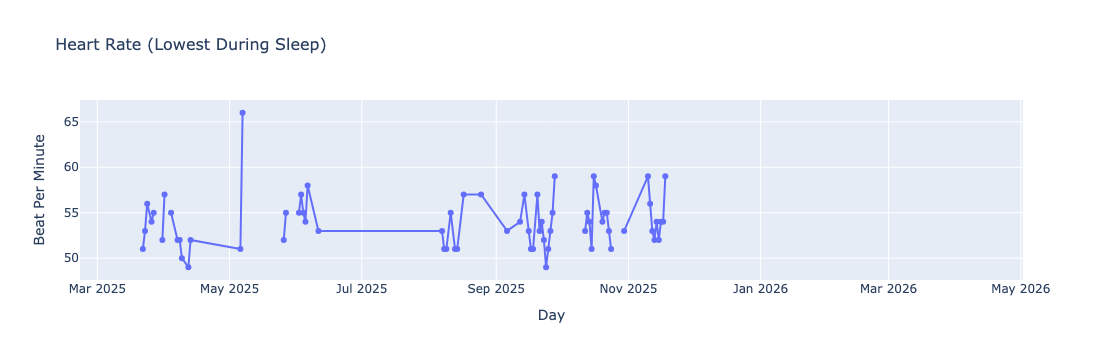


2. Respiratory Rate - Average breathing rate during sleep


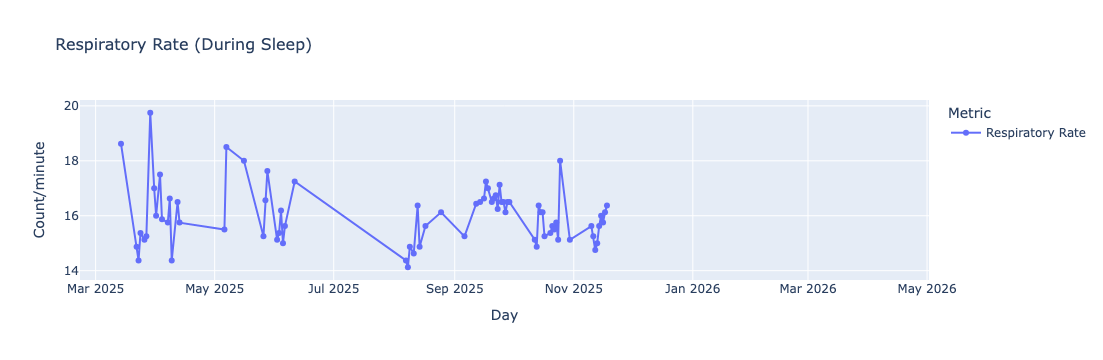


3. Oxygen Saturation (SpO2) - Average blood oxygen during sleep


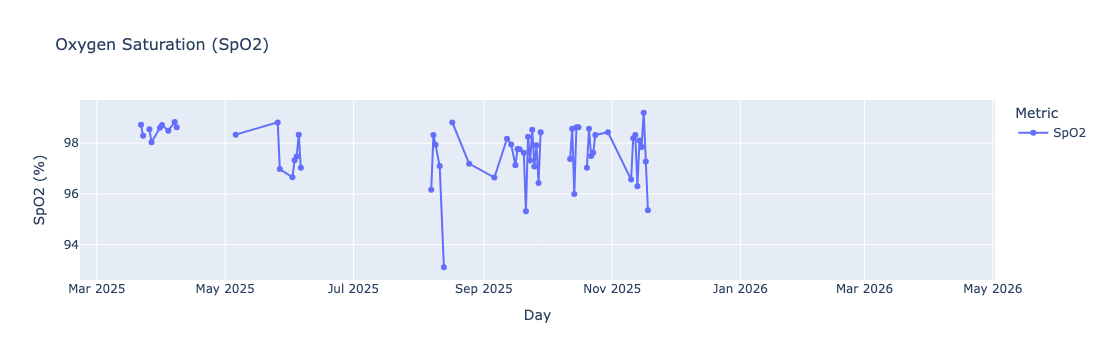


4. Heart Rate Variability (HRV) - Indicator of autonomic nervous system health


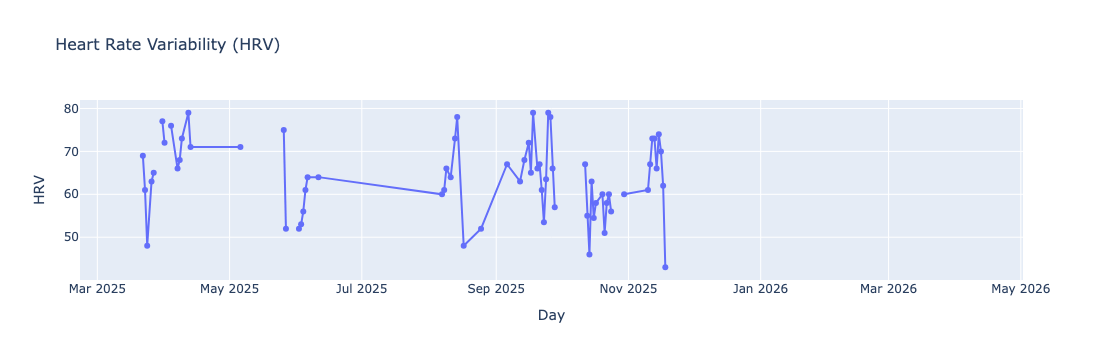


5. Sleep Stages - Deep, REM, and Light sleep breakdown


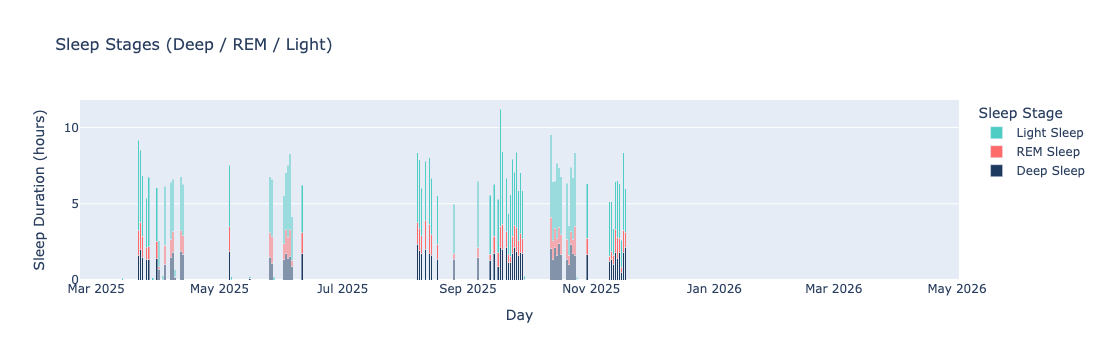


6. Total Sleep Duration - Total time asleep each day


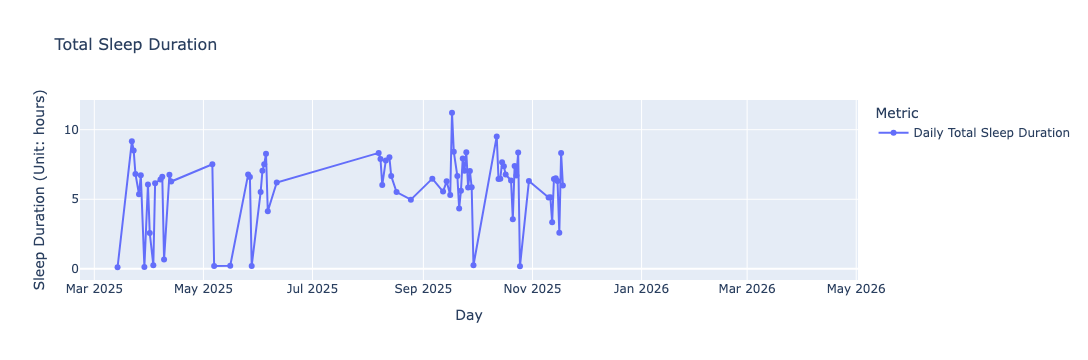


7. Daily Steps - Physical activity measure


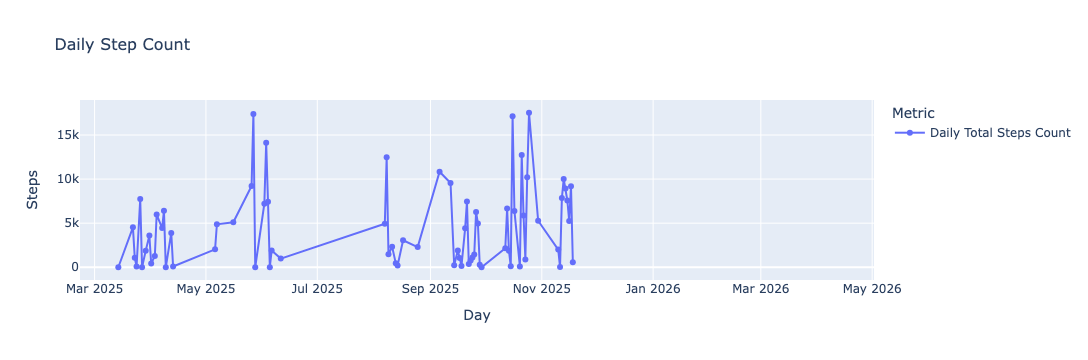


8. Temperature Deviation - Changes from personal baseline


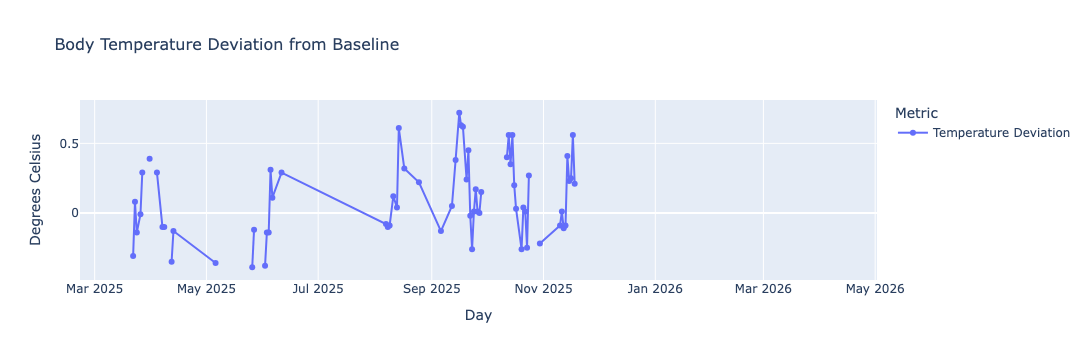


All Oura Ring visualizations complete!


In [22]:
# Calculate the adjusted end date for visualization (end_date - 1 day)
viz_end_date = str(pd.to_datetime(end_date) + pd.DateOffset(days=-1))

print(f"Visualizing Oura Ring data from {start_date} to {viz_end_date}\n")

# =============================================================================
# 1. HEART RATE (Most Important)
# =============================================================================
print("1. Heart Rate - Lowest heart rate during sleep")
lowest_hr_fig = vis.visualize_daily_lowest_hr(
    merged_oura_data, 
    start_date=start_date, 
    end_date=viz_end_date
)
lowest_hr_fig.update_layout(
    title="Heart Rate (Lowest During Sleep)",
    title_font_size=16
)
lowest_hr_fig.show()

# =============================================================================
# 2. RESPIRATORY RATE
# =============================================================================
print("\n2. Respiratory Rate - Average breathing rate during sleep")
resp_fig = vis.visualize_respiratory(
    merged_oura_data, 
    start_date=start_date, 
    end_date=viz_end_date
)
resp_fig.update_layout(
    title="Respiratory Rate (During Sleep)",
    title_font_size=16
)
resp_fig.show()

# =============================================================================
# 3. OXYGEN SATURATION (SpO2) - NEW
# =============================================================================
print("\n3. Oxygen Saturation (SpO2) - Average blood oxygen during sleep")
if not daily_spo2.empty and 'average_spo2' in daily_spo2.columns:
    spo2_fig = vis.visualize_spo2(
        daily_spo2, 
        start_date=start_date, 
        end_date=viz_end_date
    )
    spo2_fig.update_layout(
        title="Oxygen Saturation (SpO2)",
        title_font_size=16
    )
    spo2_fig.show()
else:
    print("   SpO2 data not available for this patient/date range")

# =============================================================================
# 4. HEART RATE VARIABILITY (HRV)
# =============================================================================
print("\n4. Heart Rate Variability (HRV) - Indicator of autonomic nervous system health")
hrv_fig = vis.visualize_daily_hrv(
    merged_oura_data, 
    start_date=start_date, 
    end_date=viz_end_date
)
hrv_fig.update_layout(
    title="Heart Rate Variability (HRV)",
    title_font_size=16
)
hrv_fig.show()

# =============================================================================
# 5. SLEEP STAGES (STACKED BAR CHART)
# =============================================================================
print("\n5. Sleep Stages - Deep, REM, and Light sleep breakdown")
# Check if we have the required sleep stage columns
sleep_stage_cols = ['deep_sleep_duration', 'rem_sleep_duration', 'light_sleep_duration']
has_sleep_stages = all(col in merged_oura_data.columns for col in sleep_stage_cols)

if has_sleep_stages:
    sleep_stages_fig = vis.visualize_sleep_stages_stacked(
        merged_oura_data, 
        start_date=start_date, 
        end_date=viz_end_date
    )
    sleep_stages_fig.update_layout(
        title="Sleep Stages (Deep / REM / Light)",
        title_font_size=16
    )
    sleep_stages_fig.show()
else:
    print("   Sleep stage data not available for this patient/date range")

# =============================================================================
# 6. TOTAL SLEEP DURATION (LINE CHART)
# =============================================================================
print("\n6. Total Sleep Duration - Total time asleep each day")
total_sleep_fig = vis.visualize_daily_sleep_time(
    merged_oura_data, 
    start_date=start_date, 
    end_date=viz_end_date
)
total_sleep_fig.update_layout(
    title="Total Sleep Duration",
    title_font_size=16
)
total_sleep_fig.show()

# =============================================================================
# 7. ACTIVITY (STEPS)
# =============================================================================
print("\n7. Daily Steps - Physical activity measure")
steps_fig = vis.visualize_daily_steps(
    merged_oura_data, 
    start_date=start_date, 
    end_date=viz_end_date
)
steps_fig.update_layout(
    title="Daily Step Count",
    title_font_size=16
)
steps_fig.show()

# =============================================================================
# 8. TEMPERATURE DEVIATION (Additional)
# =============================================================================
print("\n8. Temperature Deviation - Changes from personal baseline")
temp_fig = vis.visualize_temperature(
    merged_oura_data, 
    start_date=start_date, 
    end_date=viz_end_date
)
temp_fig.update_layout(
    title="Body Temperature Deviation from Baseline",
    title_font_size=16
)
temp_fig.show()

print("\n" + "="*60)
print("All Oura Ring visualizations complete!")
print("="*60)

## In-Patient Comparison: Flowsheet vs Oura Ring Data

This section compares measurements from both the flowsheet and Oura Ring for the overlapping date range.
We use Bland-Altman plots to assess agreement between the two measurement methods for:
- Heart Rate
- Respiratory Rate  
- Body Temperature

In [11]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

def create_bland_altman_plot(method1, method2, method1_name="Method 1", method2_name="Method 2", 
                              title="Bland-Altman Plot", unit=""):
    """
    Create a Bland-Altman plot to assess agreement between two measurement methods.
    
    Parameters:
    -----------
    method1 : array-like
        Measurements from first method
    method2 : array-like
        Measurements from second method
    method1_name : str
        Name of first method
    method2_name : str
        Name of second method
    title : str
        Plot title
    unit : str
        Unit of measurement
        
    Returns:
    --------
    fig : plotly figure object (None if insufficient data)
    stats_dict : dict with statistical information or error message
    """
    # Convert to numpy arrays and remove NaN values
    data = pd.DataFrame({
        'method1': method1,
        'method2': method2
    }).dropna()
    
    n_pairs = len(data)
    
    # Check for sufficient data points
    if n_pairs == 0:
        return None, {
            "error": "No overlapping data points",
            "n_pairs": 0,
            "message": "No valid paired measurements found. Check that both methods have data for the same dates."
        }
    
    if n_pairs < 2:
        return None, {
            "error": "Insufficient data points for statistical analysis",
            "n_pairs": n_pairs,
            "message": f"Only {n_pairs} paired measurement(s) found. At least 2 are required for Bland-Altman analysis."
        }
    
    m1 = data['method1'].values
    m2 = data['method2'].values
    
    # Calculate mean and difference
    mean = (m1 + m2) / 2
    diff = m1 - m2
    
    # Calculate statistics
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)
    
    # 95% limits of agreement
    upper_loa = mean_diff + 1.96 * std_diff
    lower_loa = mean_diff - 1.96 * std_diff
    
    # Pearson correlation (only if we have at least 2 points, which we do at this point)
    correlation, p_value = stats.pearsonr(m1, m2)
    
    # Create subplots: Scatter plot and Bland-Altman plot side by side
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(
            f'{method1_name} vs {method2_name}',
            'Bland-Altman Plot'
        ),
        horizontal_spacing=0.12
    )
    
    # Scatter plot (left)
    fig.add_trace(
        go.Scatter(
            x=m2, y=m1,
            mode='markers',
            name='Data points',
            marker=dict(size=8, color='blue', opacity=0.6),
            hovertemplate=f'{method2_name}: %{{x}}{unit}<br>{method1_name}: %{{y}}{unit}<extra></extra>'
        ),
        row=1, col=1
    )
    
    # Identity line
    min_val = min(np.min(m1), np.min(m2))
    max_val = max(np.max(m1), np.max(m2))
    fig.add_trace(
        go.Scatter(
            x=[min_val, max_val],
            y=[min_val, max_val],
            mode='lines',
            name='Identity line',
            line=dict(color='gray', dash='dash'),
            showlegend=True
        ),
        row=1, col=1
    )
    
    # Bland-Altman plot (right)
    fig.add_trace(
        go.Scatter(
            x=mean, y=diff,
            mode='markers',
            name='Differences',
            marker=dict(size=8, color='green', opacity=0.6),
            hovertemplate=f'Mean: %{{x:.2f}}{unit}<br>Difference: %{{y:.2f}}{unit}<extra></extra>'
        ),
        row=1, col=2
    )
    
    # Mean difference line
    fig.add_trace(
        go.Scatter(
            x=[np.min(mean), np.max(mean)],
            y=[mean_diff, mean_diff],
            mode='lines',
            name=f'Mean diff ({mean_diff:.2f})',
            line=dict(color='blue', width=2)
        ),
        row=1, col=2
    )
    
    # Upper and lower limits of agreement
    fig.add_trace(
        go.Scatter(
            x=[np.min(mean), np.max(mean)],
            y=[upper_loa, upper_loa],
            mode='lines',
            name=f'+1.96 SD ({upper_loa:.2f})',
            line=dict(color='red', dash='dash', width=1.5)
        ),
        row=1, col=2
    )
    
    fig.add_trace(
        go.Scatter(
            x=[np.min(mean), np.max(mean)],
            y=[lower_loa, lower_loa],
            mode='lines',
            name=f'-1.96 SD ({lower_loa:.2f})',
            line=dict(color='red', dash='dash', width=1.5)
        ),
        row=1, col=2
    )
    
    # Update axes
    fig.update_xaxes(title_text=f"{method2_name} ({unit})", row=1, col=1)
    fig.update_yaxes(title_text=f"{method1_name} ({unit})", row=1, col=1)
    fig.update_xaxes(title_text=f"Mean of {method1_name} and {method2_name} ({unit})", row=1, col=2)
    fig.update_yaxes(title_text=f"Difference ({method1_name} - {method2_name}) ({unit})", row=1, col=2)
    
    # Update layout
    fig.update_layout(
        title_text=title,
        height=500,
        width=1200,
        showlegend=True,
        legend=dict(x=1.05, y=1)
    )
    
    # Statistics dictionary
    stats_dict = {
        'n_pairs': n_pairs,
        'mean_diff': mean_diff,
        'std_diff': std_diff,
        'upper_loa': upper_loa,
        'lower_loa': lower_loa,
        'correlation': correlation,
        'p_value': p_value
    }
    
    return fig, stats_dict

print("Bland-Altman plot function created successfully.")

Bland-Altman plot function created successfully.


In [12]:
# Prepare flowsheet data for comparison
# Extract relevant measures from flowsheet
flowsheet_comparison = df[['__time', '__measure', '__value']].copy()

# Add day column by converting __time to date
flowsheet_comparison['__day'] = flowsheet_comparison['__time'].dt.date

# Convert flowsheet data to have one row per day with columns for each measure
flowsheet_pivot = flowsheet_comparison.pivot_table(
    index='__day',
    columns='__measure',
    values='__value',
    aggfunc='mean'  # Average if multiple measurements per day
).reset_index()

# Convert __day to string format to match Oura data
flowsheet_pivot['day'] = flowsheet_pivot['__day'].astype(str)

# Prepare Oura data for comparison
oura_comparison = merged_oura_data.copy()

# Merge flowsheet and Oura data on day
combined_data = pd.merge(
    flowsheet_pivot,
    oura_comparison,
    on='day',
    how='inner',  # Only keep days where we have both flowsheet and Oura data
    suffixes=('_flowsheet', '_oura')
)

print(f"Found {len(combined_data)} days with data from both Flowsheet and Oura Ring")
if len(combined_data) > 0:
    print(f"Date range: {combined_data['day'].min()} to {combined_data['day'].max()}")
    print(f"\nAvailable flowsheet measures ({len(flowsheet_pivot.columns)-2} total):")
    # Show first 10 flowsheet columns (excluding __day and day)
    fs_cols = [col for col in flowsheet_pivot.columns if col not in ['__day', 'day']]
    for col in fs_cols[:10]:
        print(f"  - {col}")
    if len(fs_cols) > 10:
        print(f"  ... and {len(fs_cols)-10} more")
    print(f"\nAvailable Oura measures: {[col for col in oura_comparison.columns if col != 'day']}")
else:
    print("\nWarning: No overlapping dates found between Flowsheet and Oura data!")
    print(f"Flowsheet date range: {flowsheet_pivot['day'].min()} to {flowsheet_pivot['day'].max()}")
    print(f"Oura date range: {oura_comparison['day'].min()} to {oura_comparison['day'].max()}")

Found 0 days with data from both Flowsheet and Oura Ring

Flowsheet date range: 2025-06-28 to 2025-06-30
Oura date range: 2025-03-14 to 2025-11-18


### 1. Heart Rate Comparison

In [13]:
# Heart Rate Comparison
# Note: We need to identify the correct column names for heart rate in flowsheet data
# Common names might include "Heart Rate", "HR", "HEART RATE", etc.

# Check if we have any combined data
if len(combined_data) == 0:
    print("⚠️  No overlapping dates between Flowsheet and Oura Ring data.")
    print("Cannot perform heart rate comparison.")
    print("\nPossible reasons:")
    print("  1. Date ranges don't overlap")
    print("  2. Oura API returned no data")
    print("  3. Flowsheet has no data for the patient in the selected date range")
else:
    # Try to find heart rate column in flowsheet
    hr_columns = [col for col in combined_data.columns if 'HEART' in str(col).upper() or 'HR' in str(col).upper()]
    print(f"Potential heart rate columns in flowsheet: {hr_columns}")
    
    # Use the lowest heart rate from Oura (sleep data)
    oura_hr = combined_data.get('lowest_heart_rate', pd.Series())
    
    # If we find a heart rate column in flowsheet, create the comparison
    if hr_columns:
        flowsheet_hr_col = hr_columns[0]  # Use the first match
        flowsheet_hr = combined_data[flowsheet_hr_col]
        
        print(f"\nComparing:")
        print(f"  Flowsheet: {flowsheet_hr_col}")
        print(f"  Oura: lowest_heart_rate (during sleep)")
        print(f"  Valid pairs: {pd.notna(flowsheet_hr).sum()} flowsheet, {pd.notna(oura_hr).sum()} oura")
        
        hr_fig, hr_stats = create_bland_altman_plot(
            flowsheet_hr,
            oura_hr,
            method1_name="Flowsheet HR",
            method2_name="Oura Ring HR (Sleep)",
            title="Heart Rate Comparison: Flowsheet vs Oura Ring",
            unit="bpm"
        )
        
        if hr_fig:
            hr_fig.show()
            
            print(f"\n=== Heart Rate Comparison Statistics ===")
            print(f"Number of paired measurements: {hr_stats['n_pairs']}")
            print(f"Mean difference (Flowsheet - Oura): {hr_stats['mean_diff']:.2f} bpm")
            print(f"Standard deviation of differences: {hr_stats['std_diff']:.2f} bpm")
            print(f"95% Limits of Agreement: [{hr_stats['lower_loa']:.2f}, {hr_stats['upper_loa']:.2f}] bpm")
            print(f"Pearson correlation: {hr_stats['correlation']:.3f} (p={hr_stats['p_value']:.4f})")
        else:
            print(f"\n⚠️  {hr_stats.get('error', 'Unknown error')}")
            print(f"   {hr_stats.get('message', '')}")
    else:
        print("\n⚠️  No heart rate data found in flowsheet.")
        print("Available flowsheet columns:", [col for col in combined_data.columns if col not in ['day', '__day']])

⚠️  No overlapping dates between Flowsheet and Oura Ring data.
Cannot perform heart rate comparison.

Possible reasons:
  1. Date ranges don't overlap
  2. Oura API returned no data
  3. Flowsheet has no data for the patient in the selected date range


### 2. Respiratory Rate Comparison

Potential respiratory rate columns in flowsheet: ['average_breath']

Comparing:
  Flowsheet: average_breath
  Oura: average_breath (during sleep)
  Valid pairs: 3 flowsheet, 3 oura


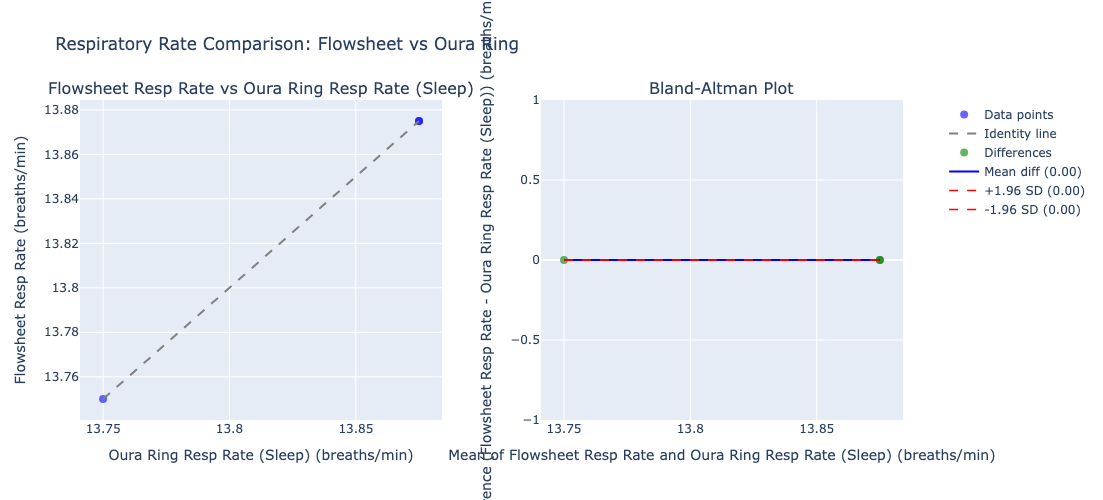


=== Respiratory Rate Comparison Statistics ===
Number of paired measurements: 3
Mean difference (Flowsheet - Oura): 0.00 breaths/min
Standard deviation of differences: 0.00 breaths/min
95% Limits of Agreement: [0.00, 0.00] breaths/min
Pearson correlation: 1.000 (p=0.0000)


In [16]:
# Respiratory Rate Comparison
# Try to find respiratory rate column in flowsheet
resp_columns = [col for col in combined_data.columns if 'RESP' in str(col).upper() or 'BREATH' in str(col).upper()]
print(f"Potential respiratory rate columns in flowsheet: {resp_columns}")

# Use the average breath rate from Oura (sleep data)
oura_resp = combined_data['average_breath']

# If we find a respiratory rate column in flowsheet, create the comparison
if resp_columns:
    flowsheet_resp_col = resp_columns[0]  # Use the first match
    flowsheet_resp = combined_data[flowsheet_resp_col]
    
    print(f"\nComparing:")
    print(f"  Flowsheet: {flowsheet_resp_col}")
    print(f"  Oura: average_breath (during sleep)")
    print(f"  Valid pairs: {pd.notna(flowsheet_resp).sum()} flowsheet, {pd.notna(oura_resp).sum()} oura")
    
    resp_fig, resp_stats = create_bland_altman_plot(
        flowsheet_resp,
        oura_resp,
        method1_name="Flowsheet Resp Rate",
        method2_name="Oura Ring Resp Rate (Sleep)",
        title="Respiratory Rate Comparison: Flowsheet vs Oura Ring",
        unit="breaths/min"
    )
    
    if resp_fig:
        resp_fig.show()
        
        print(f"\n=== Respiratory Rate Comparison Statistics ===")
        print(f"Number of paired measurements: {resp_stats['n_pairs']}")
        print(f"Mean difference (Flowsheet - Oura): {resp_stats['mean_diff']:.2f} breaths/min")
        print(f"Standard deviation of differences: {resp_stats['std_diff']:.2f} breaths/min")
        print(f"95% Limits of Agreement: [{resp_stats['lower_loa']:.2f}, {resp_stats['upper_loa']:.2f}] breaths/min")
        print(f"Pearson correlation: {resp_stats['correlation']:.3f} (p={resp_stats['p_value']:.4f})")
    else:
        print(f"\n{resp_stats}")
else:
    print("\nNo respiratory rate data found in flowsheet. Skipping respiratory rate comparison.")
    print("Available flowsheet columns:", combined_data.columns.tolist())

### 3. Body Temperature Comparison

Potential temperature columns in flowsheet: ['temperature_deviation']

Note: Temperature comparison is challenging because:
  - Flowsheet likely contains absolute temperature (°F or °C)
  - Oura Ring provides temperature_deviation from baseline (°C)

To enable comparison, we would need:
  1. The patient's baseline temperature from Oura
  2. Or convert flowsheet temps to deviations from patient average

Approximating comparison by converting flowsheet to deviations:
  Flowsheet mean temperature: -0.19
  Flowsheet temperature deviation range: [-0.12, 0.21]
  Oura temperature deviation range: [-0.31, 0.02]
  Valid pairs: 3 flowsheet, 3 oura


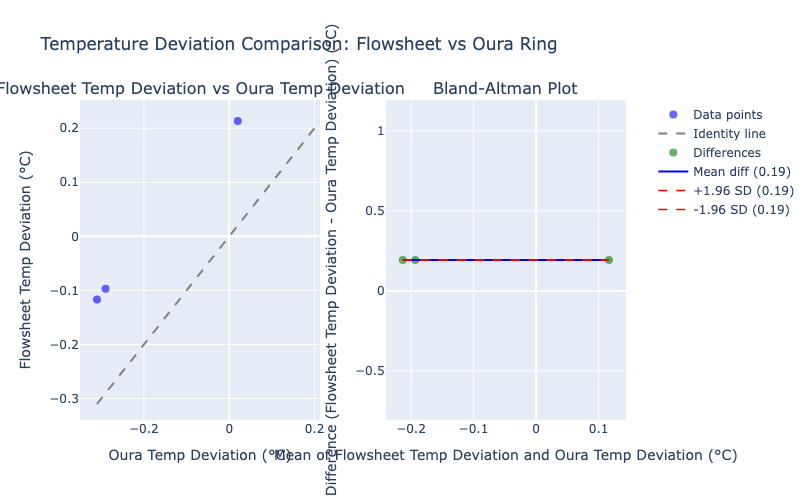


=== Temperature Deviation Comparison Statistics ===
Number of paired measurements: 3
Mean difference (Flowsheet - Oura): 0.193 °C
Standard deviation of differences: 0.000 °C
95% Limits of Agreement: [0.193, 0.193] °C
Pearson correlation: 1.000 (p=0.0000)

Interpretation: This compares temperature deviations from each method's baseline.


In [17]:
# Body Temperature Comparison
# Try to find temperature column in flowsheet
temp_columns = [col for col in combined_data.columns if 'TEMP' in str(col).upper()]
print(f"Potential temperature columns in flowsheet: {temp_columns}")

# Oura provides temperature_deviation (deviation from baseline), not absolute temperature
# We cannot directly compare this to flowsheet temperature unless we have the baseline
oura_temp_dev = combined_data['temperature_deviation']

# If we find a temperature column in flowsheet, we need to be careful about the comparison
if temp_columns:
    flowsheet_temp_col = temp_columns[0]  # Use the first match
    flowsheet_temp = combined_data[flowsheet_temp_col]
    
    print(f"\nNote: Temperature comparison is challenging because:")
    print(f"  - Flowsheet likely contains absolute temperature (°F or °C)")
    print(f"  - Oura Ring provides temperature_deviation from baseline (°C)")
    print(f"\nTo enable comparison, we would need:")
    print(f"  1. The patient's baseline temperature from Oura")
    print(f"  2. Or convert flowsheet temps to deviations from patient average")
    
    # Calculate flowsheet temperature deviation from its mean as an approximation
    flowsheet_temp_mean = flowsheet_temp.mean()
    flowsheet_temp_deviation = flowsheet_temp - flowsheet_temp_mean
    
    print(f"\nApproximating comparison by converting flowsheet to deviations:")
    print(f"  Flowsheet mean temperature: {flowsheet_temp_mean:.2f}")
    print(f"  Flowsheet temperature deviation range: [{flowsheet_temp_deviation.min():.2f}, {flowsheet_temp_deviation.max():.2f}]")
    print(f"  Oura temperature deviation range: [{oura_temp_dev.min():.2f}, {oura_temp_dev.max():.2f}]")
    print(f"  Valid pairs: {pd.notna(flowsheet_temp_deviation).sum()} flowsheet, {pd.notna(oura_temp_dev).sum()} oura")
    
    temp_fig, temp_stats = create_bland_altman_plot(
        flowsheet_temp_deviation,
        oura_temp_dev,
        method1_name="Flowsheet Temp Deviation",
        method2_name="Oura Temp Deviation",
        title="Temperature Deviation Comparison: Flowsheet vs Oura Ring",
        unit="°C"
    )
    
    if temp_fig:
        temp_fig.show()
        
        print(f"\n=== Temperature Deviation Comparison Statistics ===")
        print(f"Number of paired measurements: {temp_stats['n_pairs']}")
        print(f"Mean difference (Flowsheet - Oura): {temp_stats['mean_diff']:.3f} °C")
        print(f"Standard deviation of differences: {temp_stats['std_diff']:.3f} °C")
        print(f"95% Limits of Agreement: [{temp_stats['lower_loa']:.3f}, {temp_stats['upper_loa']:.3f}] °C")
        print(f"Pearson correlation: {temp_stats['correlation']:.3f} (p={temp_stats['p_value']:.4f})")
        print(f"\nInterpretation: This compares temperature deviations from each method's baseline.")
    else:
        print(f"\n{temp_stats}")
else:
    print("\nNo temperature data found in flowsheet. Skipping temperature comparison.")
    print("Available flowsheet columns:", combined_data.columns.tolist())